#  Job Recommendation System

## Problem Definition — Job Role Recommender

Many job seekers know their skills but aren't sure which job roles best match them, or what skills they're missing for a role they want. Manually browsing thousands of job postings to figure this out is time-consuming and inefficient.

Goal: Build a system that takes a user's skills as input and:

Recommends the job roles/titles that best match those skills.
Identifies missing skills needed for a target role, so users know what to learn next.

Why it matters: Helps job seekers make informed career decisions and focus their skill development instead of guessing.

Data source: LinkedIn Jobs & Skills 2024 dataset [Kaggle](https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024) — ~1.3M job postings with titles, skills, level, type, and descriptions 

## 1. Import Libraries

In [1]:
import os

import pandas as pd
import kagglehub

import matplotlib.pyplot as plt
import seaborn as sns

# class
from filtering import Filtering

c:\Users\computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  2. Data Loading

In [2]:
path = kagglehub.dataset_download("asaniczka/1-3m-linkedin-jobs-and-skills-2024")
jobs_df = pd.read_csv(os.path.join(path, 'linkedin_job_postings.csv'))
skills_df = pd.read_csv(f"{path}/job_skills.csv")

# Merge datasets
merged_df = jobs_df.merge(skills_df, on="job_link", how="inner")


print(f"Jobs Dataset: {jobs_df.shape}")
print(f"Skills Dataset: {skills_df.shape}")
print(f"Merged Dataset: {merged_df.shape}")

Jobs Dataset: (1348454, 14)
Skills Dataset: (1296381, 2)
Merged Dataset: (1296381, 15)


# 3. EDA + Preprocessing

## EDA Questions

1. What are the most common job titles? → **Chart 1**
2. How are job levels split (Entry, Mid-Senior, etc.)? → **Chart 2**
3. How are job types split (Full-time, Part-time, etc.)? → **Chart 3**
4. How many skills does a typical job ask for? → **Chart 4**
5. What are the top skills overall? → **Chart 5**
6. What skills does each job title need most? → **Chart 6**
7. How many skills does each job title need on average? → **Chart 7**
8. Do skill needs change by job level or job type? → **Chart 8**
9. What are the most common job locations? → **Chart 9**
10. Do skill needs change by company? → **Chart 10**
11. Which companies hire the most? → **Chart 11**
12. Do top companies hire more Senior or Entry level? → **Chart 12**
13. Do companies hire for many job titles or just a few? → **Chart 13**

In [3]:
df = merged_df.copy()

In [4]:
# Check missing values

((df.isnull().sum() / len(df)) * 100)[df.isnull().sum()>0]

company         0.000694
job_location    0.001466
job_skills      0.160832
dtype: float64

In [5]:
# Remove missing values

df = df.dropna()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(1294268, 15)

In [8]:
df.head()

,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 08:08:19.663033+00,t,t,f,Registered Nurse (RN),Trinity Health MI,"Muskegon, MI",2024-01-14,Muskegon,United States,Nurse Practitioner,Mid senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur..."


In [9]:
df.columns

Index(['job_link', 'last_processed_time', 'got_summary', 'got_ner',
       'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen',
       'search_city', 'search_country', 'search_position', 'job_level',
       'job_type', 'job_skills'],
      dtype='str')

In [ ]:
# drop scraper flags column becase it's add zero value to our project

df = df.drop(columns=["job_link","last_processed_time", "got_summary", "got_ner", "is_being_worked", "search_city", "search_country", "search_position"])

print(df.shape)
df.head()

(1294268, 10)


,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills
0,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,Registered Nurse (RN),Trinity Health MI,"Muskegon, MI",2024-01-14,Muskegon,United States,Nurse Practitioner,Mid senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur..."


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 1294268 entries, 0 to 1296380
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype
---  ------           --------------    -----
 0   job_title        1294268 non-null  str  
 1   company          1294268 non-null  str  
 2   job_location     1294268 non-null  str  
 3   first_seen       1294268 non-null  str  
 4   search_city      1294268 non-null  str  
 5   search_country   1294268 non-null  str  
 6   search_position  1294268 non-null  str  
 7   job_level        1294268 non-null  str  
 8   job_type         1294268 non-null  str  
 9   job_skills       1294268 non-null  str  
dtypes: str(10)
memory usage: 785.6 MB


In [12]:
df.duplicated().sum()

np.int64(136)

In [13]:
df = df.drop_duplicates()
df.shape

(1294132, 10)

After removing unnecessary columns, 136 duplicate records were detected. These duplicates were not present in the original dataset (`merged_df`), but appeared because the removed columns contained distinguishing information between records. Once those columns were removed, multiple rows became identical across the remaining features. Therefore, duplicate records were removed to keep only unique observations.

## Job Titles

In [ ]:
df["job_title"] = df["job_title"].str.lower().str.strip().str.replace(r"[,/-_]", " ", regex=True).str.title()

In [ ]:
job_filter = Filtering(df, "job_title", 0.9, 95, 0.9)
df["job_title_c"] = job_filter.run()

Loading existing mappings...
Done


In [17]:
df[["job_title", "job_title_c"]].head(5)

,job_title,job_title_c
0,Account Executive - Dispensing (Norcal/Norther...,Account Executive - Dispensing - Becton Dickinson
1,Registered Nurse - Rn Care Manager,Nurse Care Manager
2,Restaurant Supervisor - The Forklift,Restaurant Supervisor
3,Independent Real Estate Agent,Independent Real Estate Agent
4,Registered Nurse (Rn),Registered Nurse


### Chart 1: Top 10 Most In-Demand Job Titles

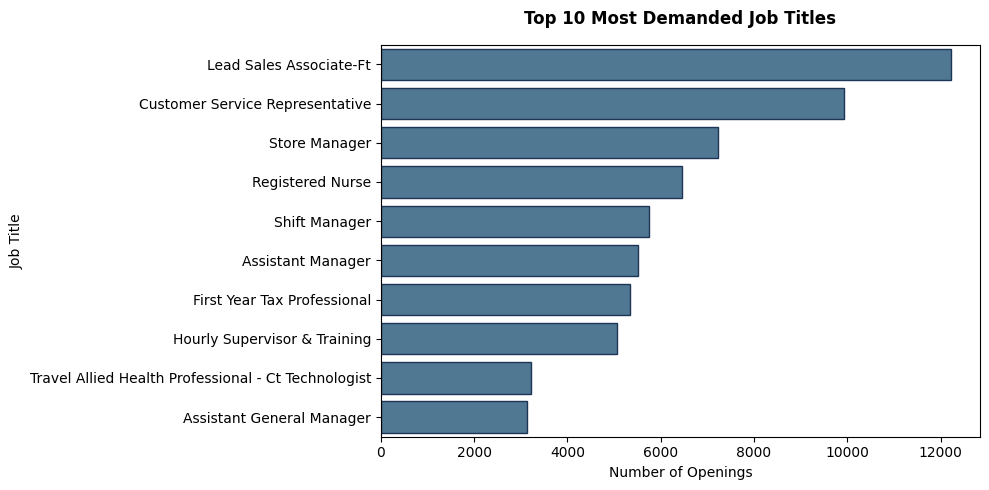

In [18]:
top_titles = df['job_title_c'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_titles.values, y=top_titles.index, color='#457b9d', edgecolor='#1d3557')
plt.title('Top 10 Most Demanded Job Titles', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Openings', fontsize=10)
plt.ylabel('Job Title', fontsize=10)
plt.tight_layout()
plt.show()

**Key Insight:**

The analysis reveals that the most demanded roles are heavily concentrated in Sales and Operations (e.g., Lead Sales Associate and Customer Service Representative). This indicates that the job market represented in this dataset strongly favors client-facing and operational positions, which should be accounted for when tuning the recommendation engine.

## Job Levels & Job Type

In [19]:
# standardize job_level/job_type formatting to prevent hidden inconsistencies
df["job_level"] = df["job_level"].str.strip().str.title()
df["job_type"] = df["job_type"].str.strip().str.title()

print(df["job_level"].value_counts())
print("\n----------------\n")
print(df["job_type"].value_counts())

job_level
Mid Senior    1153231
Associate      140901
Name: count, dtype: int64

----------------

job_type
Onsite    1283318
Hybrid       6560
Remote       4254
Name: count, dtype: int64


### Chart 2: Distribution of Job Levels

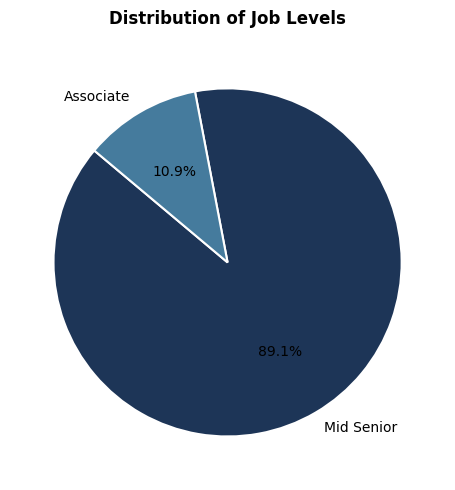

In [20]:
job_levels = df['job_level'].value_counts()

blue_shades = ['#1d3557', '#457b9d', '#a8dadc']

plt.figure(figsize=(10, 5))
plt.pie(
    job_levels.values, 
    labels=job_levels.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=blue_shades,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribution of Job Levels', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Key Insight:**

The data demonstrates a significant class imbalance across career levels, where Mid-Senior level positions dominate with 89.1% of total listings, compared to just 10.9% for Associate roles. This suggests the dataset primarily caters to experienced professionals rather than entry-level candidates.

### Chart 3: Distribution of Job Types

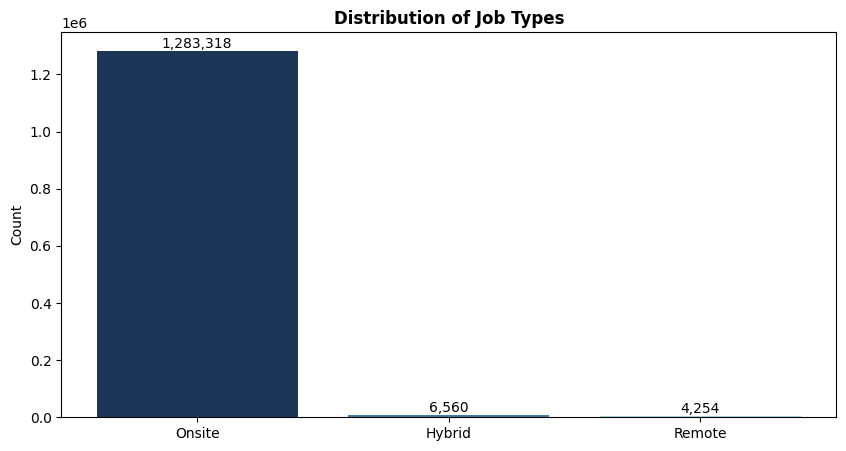

In [21]:
job_types = df['job_type'].value_counts()

colors = ['#1d3557', '#457b9d', '#a8dadc']

plt.figure(figsize=(10,5))
bars = plt.bar(job_types.index, job_types.values, color=colors)

plt.title('Distribution of Job Types', fontsize=12, fontweight='bold')
plt.ylabel('Count')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,}',
        ha='center',
        va='bottom'
    )

plt.show()

## Skills

In [22]:
skill_filter = Filtering(df, "job_skills", 0.8, 95, 0.9)
df["job_skills_c"] = skill_filter.run()

Loading existing mappings...
Done


In [24]:
df[["job_skills", "job_skills_c"]].head(5)

,job_skills,job_skills_c
0,"Medical equipment sales, Key competitors, Term...","[medical sales, key competitors, terminology, ..."
1,"Nursing, Bachelor of Science in Nursing, Maste...","[nursing, master's degree in nursing, patient ..."
2,"Restaurant Operations Management, Inventory Ma...","[restaurant operations, inventory management, ..."
3,"Real Estate, Customer Service, Sales, Negotiat...","[real estate, customer service, sales, negotia..."
4,"Nursing, BSN, Medical License, Virtual RN, Nur...","[nursing, bsn, medical license, virtual rn, nu..."


### Chart 4: Skill Count Distribution

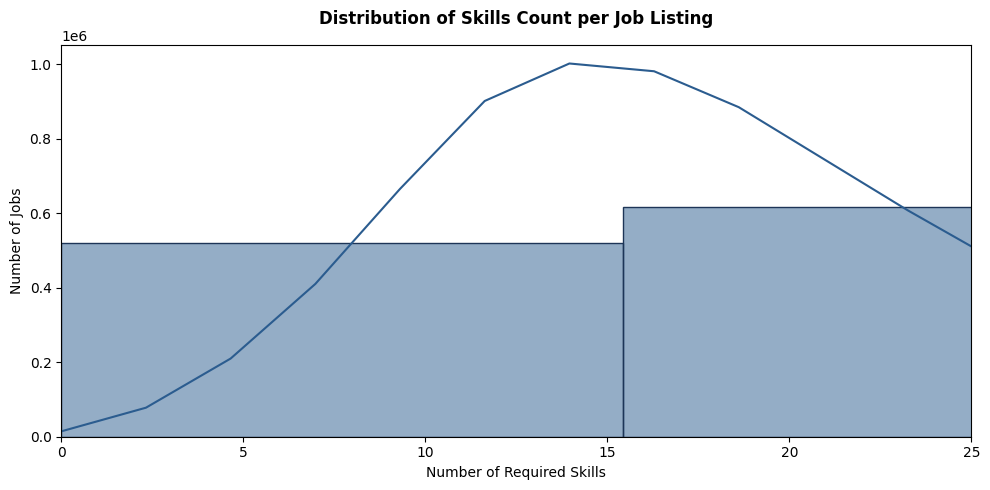

In [25]:
num_skills = df['job_skills_c'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(num_skills, bins=30, kde=True, color='#2b5c8f', edgecolor='#1d3557')
plt.title('Distribution of Skills Count per Job Listing', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Required Skills', fontsize=10)
plt.ylabel('Number of Jobs', fontsize=10)
plt.xlim(0, 25)
plt.tight_layout()
plt.show()

**Insight:** Most jobs ask for 15 to 17 skills. So the recommender should show about 10 to 15 key skills for each job.

### Chart 5: Top 15 Demanded Skills

In [26]:
top_skills = df["job_skills_c"].explode().value_counts().reset_index().head(15)
top_skills.columns = ['skill', 'count']
top_skills

,skill,count
0,communication,582765
1,customer service,295381
2,teamwork,236786
3,leadership,209771
4,problemsolving,171893
5,time management,157054
6,problem solving,153944
7,attention to detail,136185
8,project management,125403
9,interpersonal,106332


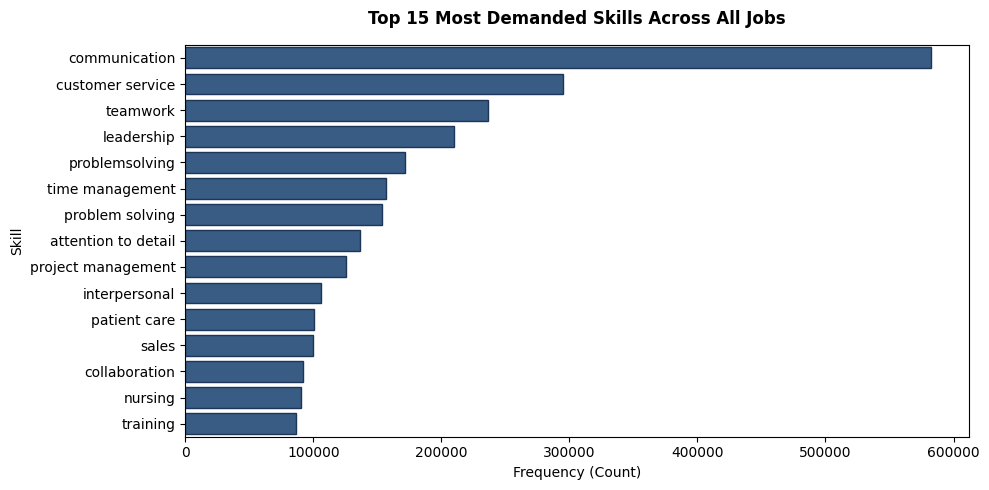

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='skill', data=top_skills, color='#2b5c8f', edgecolor='#1d3557')
plt.title('Top 15 Most Demanded Skills Across All Jobs', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Frequency (Count)', fontsize=10)
plt.ylabel('Skill', fontsize=10)
plt.tight_layout()
plt.show()

**Key Insights:**

Dominance of Soft Skills: The chart clearly demonstrates that foundational soft skills are the most frequently requested qualifications across all listings. "Communication" leads as the top demanded skill overall (surpassing 370,000 occurrences), closely followed by "Customer Service" (~280,000) and "Teamwork" (~230,000).

Dominant Skill Categories: The top demanded competencies span across four primary categories: Communication (Communication, Communication Skills, Interpersonal Skills), Leadership & Management (Leadership, Project Management), Analytical Thinking (Problem Solving, Attention To Detail), and Domain-Specific Roles (Sales, Patient Care, Nursing).

Data Preprocessing Note: Duplicate variations of identical skills were identified in the raw data (e.g., "Communication" vs. "Communication Skills" and "Problem Solving" vs. "Problemsolving"). Standardizing these terms during text preprocessing will refine the skill-matching accuracy for the recommendation engine.

### Chart 6: Top Skills per Job Title

In [29]:
def top_skills_for_role(role, n=10):
    
    rows = df[df['job_title_c'] == role]

    all_skills = []
    for skill_list in rows['job_skills_c']:
        for skill in skill_list:
            all_skills.append(skill)

    return pd.Series(all_skills).value_counts().head(n)

example_role = top_titles.index[0]
print(f"Top skills for: {example_role}")
top_skills_for_role(example_role)

Top skills for: Lead Sales Associate-Ft


customer service               11755
supervisory experience         10716
mathematical calculations       9203
high school diploma             8403
cash handling                   7467
planogram implementation        6076
cash register operation         6061
ibm cash register functions     5664
communication                   5662
cash handling procedures        5628
Name: count, dtype: int64

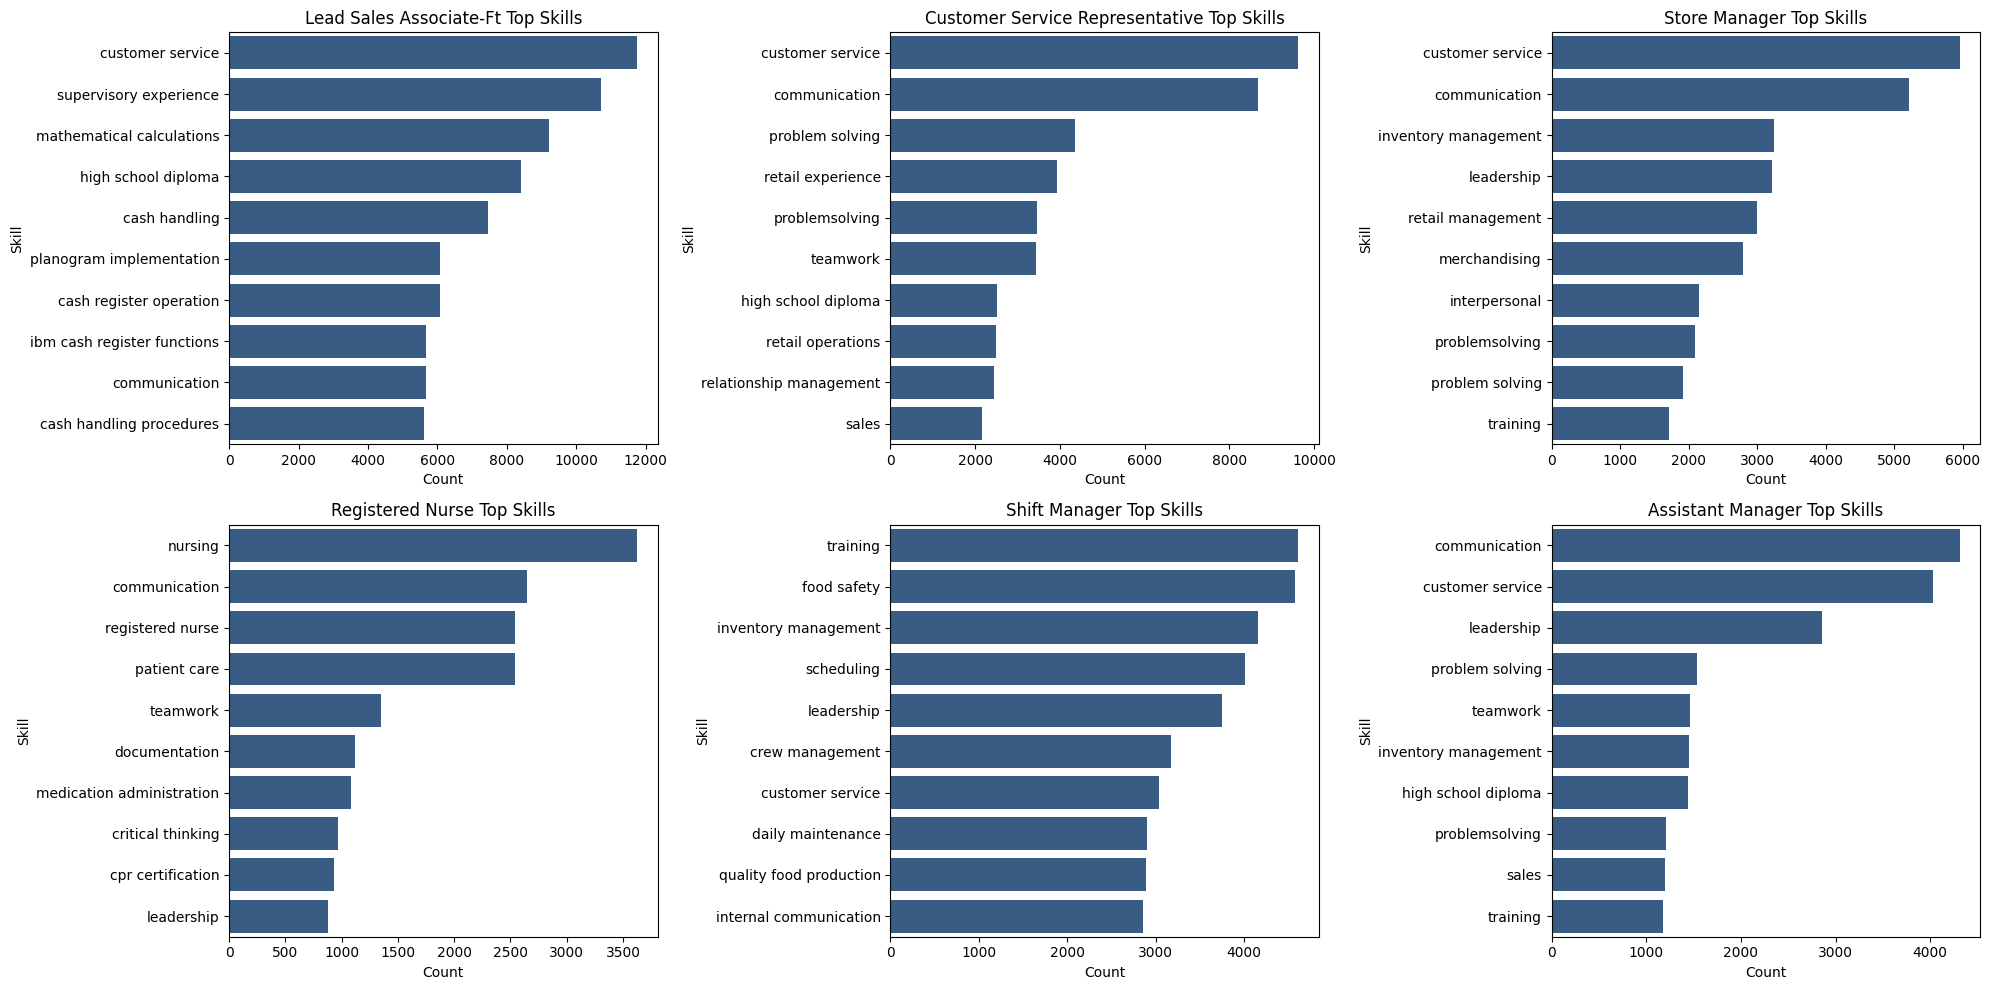

In [36]:
top6_titles = top_titles.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, role in enumerate(top6_titles):
    role_top_skills = top_skills_for_role(role)

    sns.barplot(
        x=role_top_skills.values,
        y=role_top_skills.index,
        color='#2b5c8f',
        ax=axes[i]
    )

    axes[i].set_title(f"{role} Top Skills")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Skill")

plt.tight_layout()
plt.show()

Each job title has different top skills. Example: "Customer Service Representative" needs customer service and communication. "Store Manager" needs customer service, leadership, and retail management. This shows skills alone can tell jobs apart.

### Chart 7: Average Skill Count by Job Title

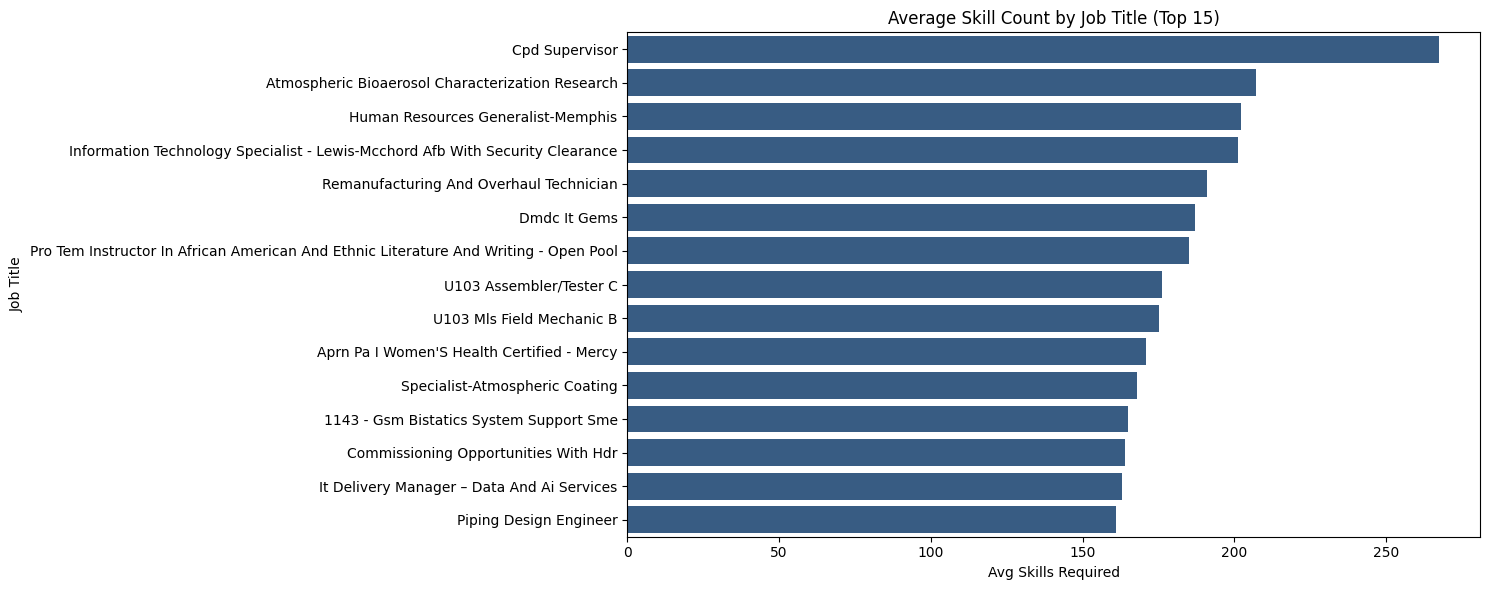

In [40]:
df['n_skills'] = df['job_skills_c'].apply(len)

# average skill count per job title
skill_counts_by_title = df.groupby('job_title_c')['n_skills'].mean()
skill_counts_by_title = skill_counts_by_title.sort_values(ascending=False).head(15)

plt.figure(figsize=(15, 6))
sns.barplot(x=skill_counts_by_title.values, y=skill_counts_by_title.index, color='#2b5c8f')
plt.title('Average Skill Count by Job Title (Top 15)')
plt.xlabel('Avg Skills Required')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

**Insight:** Different jobs need different numbers of skills. This helps us know how many skills a user is missing for a job.

### Chart 8: Skill Demand by Job Level and Job Type

job_level
Mid Senior    19.699019
Associate     19.058076
Name: n_skills, dtype: float64


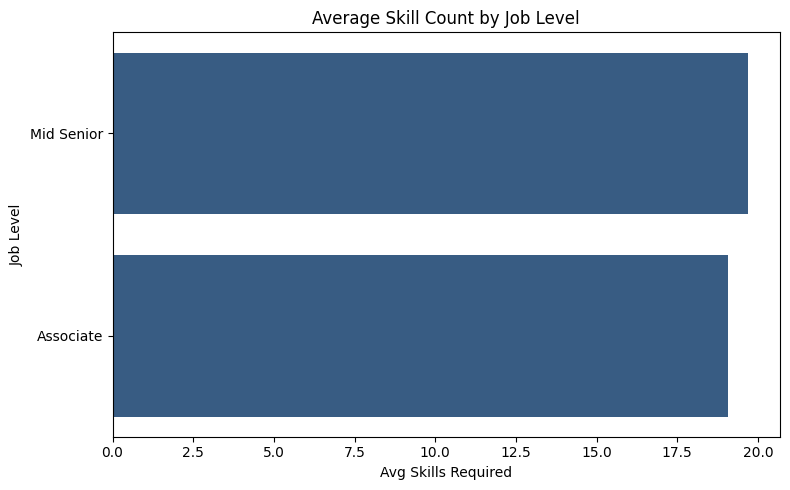

In [41]:
skills_by_level = df.groupby('job_level')['n_skills'].mean()
skills_by_level = skills_by_level.sort_values(ascending=False)
print(skills_by_level)

plt.figure(figsize=(8, 5))
sns.barplot(x=skills_by_level.values, y=skills_by_level.index, color='#2b5c8f')
plt.title('Average Skill Count by Job Level')
plt.xlabel('Avg Skills Required')
plt.ylabel('Job Level')
plt.tight_layout()
plt.show()

job_type
Remote    22.399154
Hybrid    21.438567
Onsite    19.610804
Name: n_skills, dtype: float64


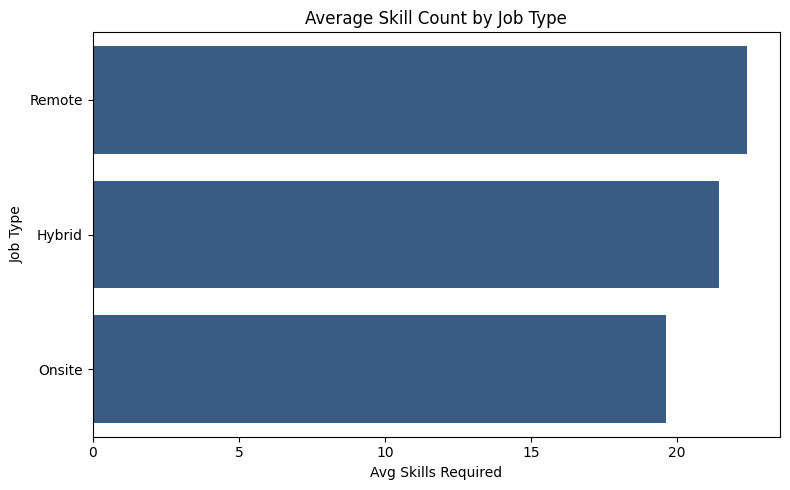

In [43]:
skills_by_type = df.groupby('job_type')['n_skills'].mean()
skills_by_type = skills_by_type.sort_values(ascending=False)
print(skills_by_type)

plt.figure(figsize=(8, 5))
sns.barplot(x=skills_by_type.values, y=skills_by_type.index, color='#2b5c8f')
plt.title('Average Skill Count by Job Type')
plt.xlabel('Avg Skills Required')
plt.ylabel('Job Type')
plt.tight_layout()
plt.show()

**Insight:** Full-time and Senior jobs may need more skills than Part-time and Entry jobs. The recommender should think about job level and type, not just skill count.

### Chart 9: Top Job Locations

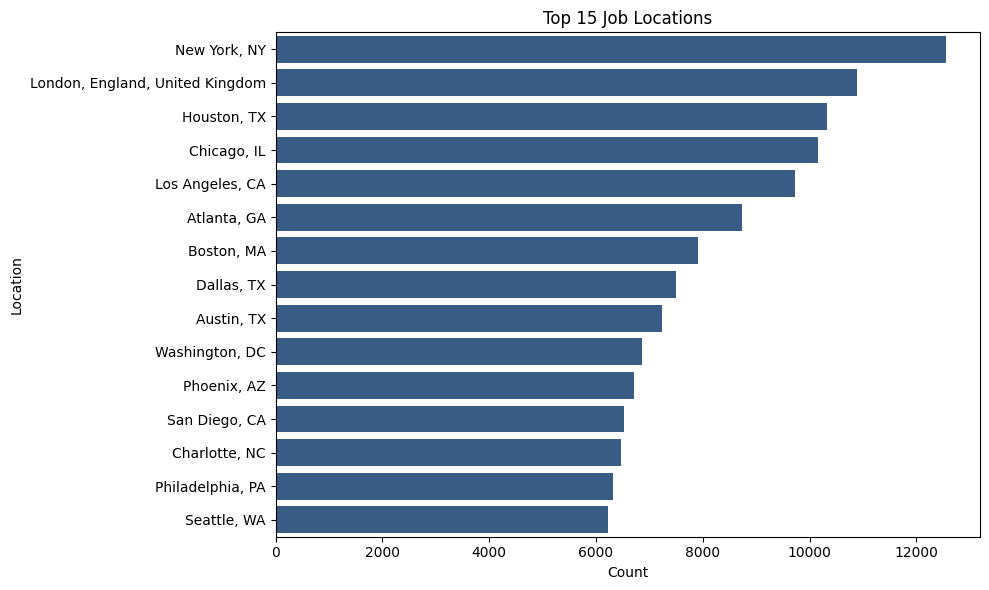

In [44]:
top_locations = df['job_location'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, color='#2b5c8f')
plt.title('Top 15 Job Locations')
plt.xlabel('Count')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

**Insight:** Most jobs come from a few cities. This shows where most job seekers and companies are.

### Chart 10: Average Skill Count by Company

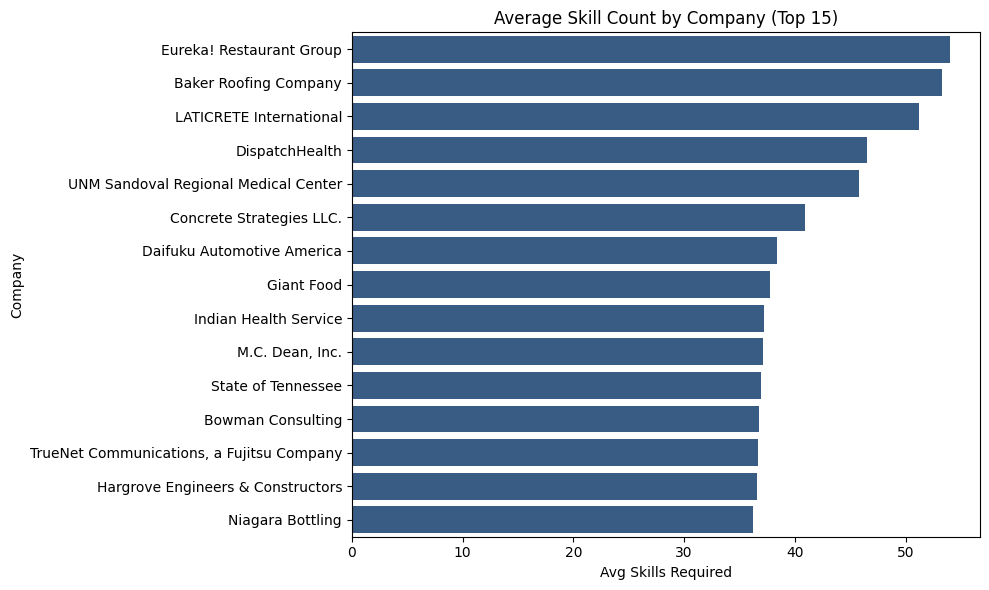

In [46]:
company_counts = df['company'].value_counts()
frequent_companies = company_counts[company_counts >= 50].index

df_frequent = df[df['company'].isin(frequent_companies)]

skills_by_company = df_frequent.groupby('company')['n_skills'].mean()
skills_by_company = skills_by_company.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=skills_by_company.values, y=skills_by_company.index, color='#2b5c8f')
plt.title('Average Skill Count by Company (Top 15)')
plt.xlabel('Avg Skills Required')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

**Insight:** Some companies ask for more skills than others. This shows if certain companies want more skilled workers.

### Chart 11: Top Hiring Companies

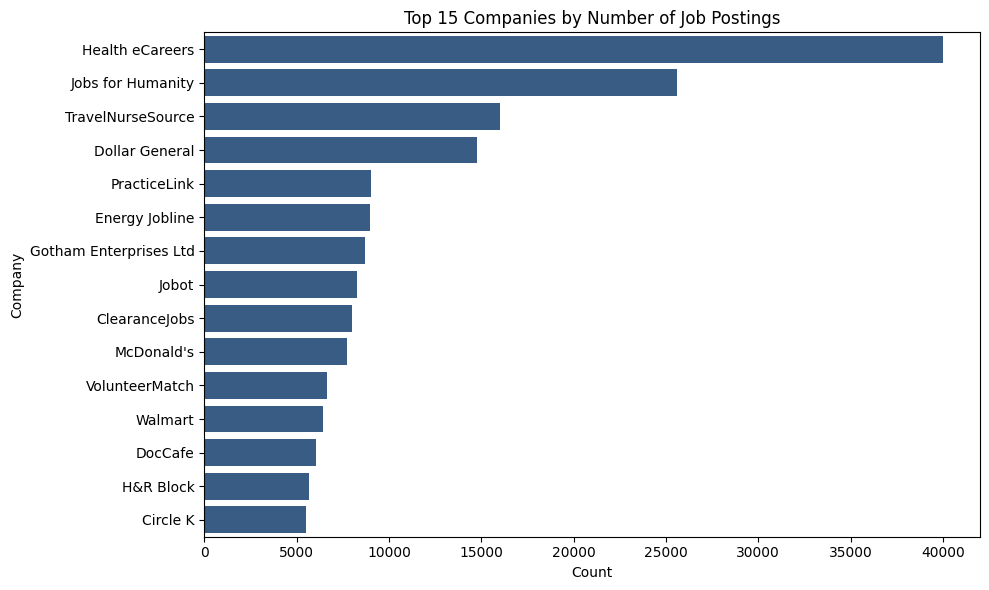

In [47]:
top_companies = df['company'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, color='#2b5c8f')
plt.title('Top 15 Companies by Number of Job Postings')
plt.xlabel('Count')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

**Insight:** A few companies post most of the jobs. This shows which companies hire the most.

### Chart 12: Job Level Mix for Top Companies

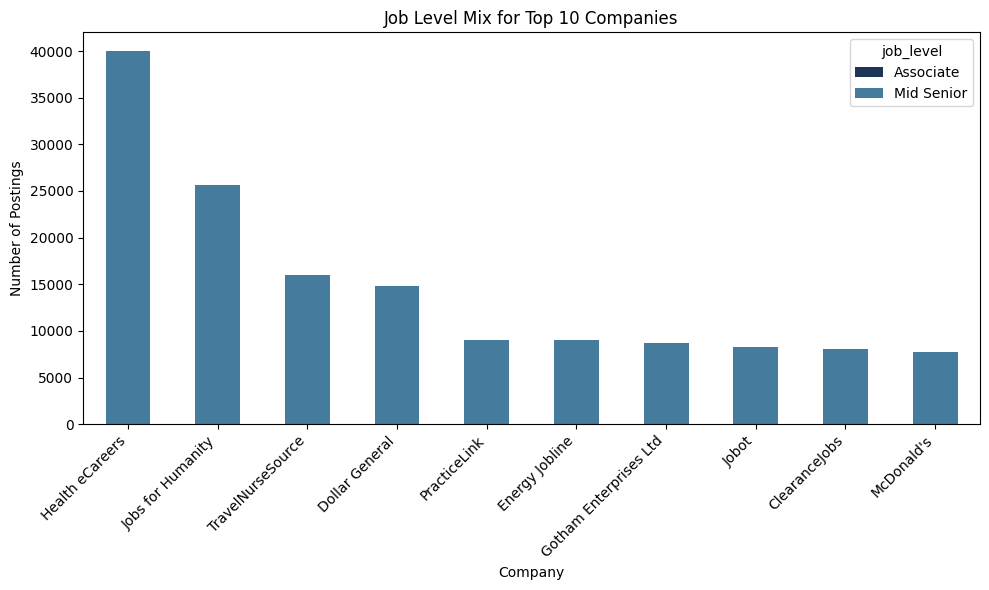

In [48]:
company_counts = df['company'].value_counts()
top_10_companies = company_counts.head(10).index

df_top_companies = df[df['company'].isin(top_10_companies)]

level_by_company = pd.crosstab(df_top_companies['company'], df_top_companies['job_level'])
level_by_company = level_by_company.loc[top_10_companies]

level_by_company.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1d3557', '#457b9d', '#a8dadc'])
plt.title('Job Level Mix for Top 10 Companies')
plt.xlabel('Company')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** Some companies hire mostly Senior workers. Others hire more Entry-level workers. This can help match users to the right company, not just the right job.

### Chart 13: Job Title Variety per Company

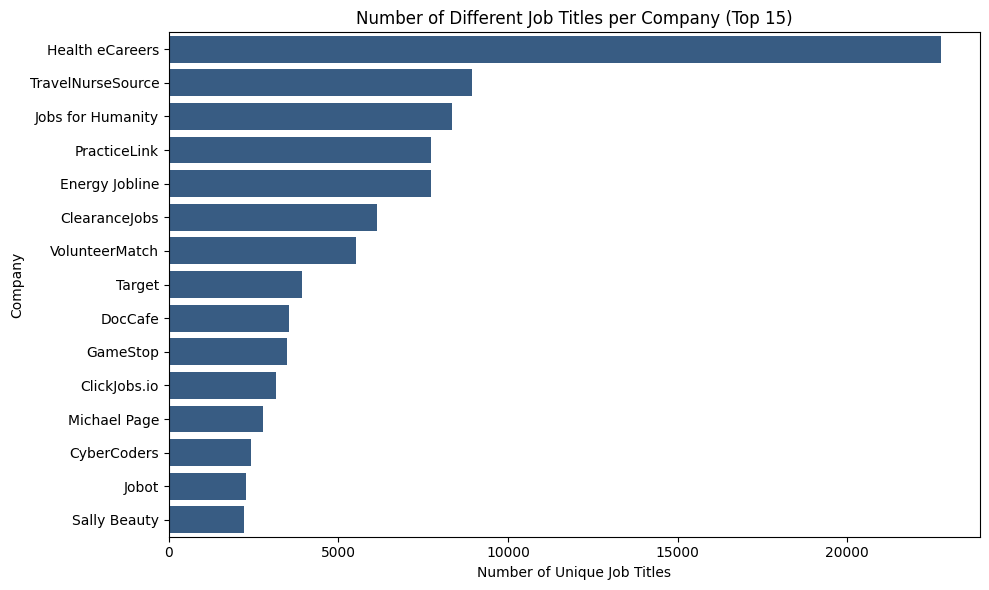

In [49]:
company_counts = df['company'].value_counts()
frequent_companies = company_counts[company_counts >= 50].index

df_frequent = df[df['company'].isin(frequent_companies)]

titles_per_company = df_frequent.groupby('company')['job_title'].nunique()
titles_per_company = titles_per_company.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=titles_per_company.values, y=titles_per_company.index, color='#2b5c8f')
plt.title('Number of Different Job Titles per Company (Top 15)')
plt.xlabel('Number of Unique Job Titles')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

**Insight:** Some companies hire for many different jobs. Other companies hire for just a few job types. This shows if a company is broad or specialized.

# Save data

In [ ]:
df.head()

In [ ]:
#df.to_csv("linkedin-jobs-and-skills.csv", index=False)